#INTRODUCCION:
*El material particulado fino (PM2.5) constituye uno de los principales contaminantes atmosféricos asociados a riesgos significativos para la salud humana y el ambiente [1]. En este contexto, la modelación estadística mediante técnicas de aprendizaje automático permite analizar relaciones entre variables ambientales y estimar concentraciones futuras [2]. El presente estudio tiene como objetivo implementar un modelo de regresión lineal para predecir la cantidad de PM 2.5 en el condado AL Lowrence utilizando datos correspondientes a los años 2024 y 2025, evaluando su capacidad predictiva con los datos reales*

# METODOLOGIA:
*Se empleó un enfoque de aprendizaje supervisado basado en regresión lineal múltiple, ampliamente utilizado en problemas de predicción continua [2]. Los datos fueron integrados a partir de dos archivos CSV correspondientes a los años 2024 y 2025.

Procesamiento de datos:

Unión de datasets mediante concatenación.
Limpieza de datos: eliminación de valores nulos.
Transformación de variables temporales a partir de la fecha (año, mes, día).
Codificación de variables categóricas (State, County, Source) mediante One-Hot Encoding, técnica estándar en aprendizaje automático para variables cualitativas [3].

Definición del modelo:

Variable dependiente: concentración media diaria de PM2.5.
Variables independientes: índice de calidad del aire (AQI), variables temporales, variables categóricas y métricas de observación.

Entrenamiento y validación:

División de datos: 80% entrenamiento, 20% prueba.
Modelo utilizado: regresión lineal ordinaria (Ordinary Least Squares), que minimiza el error cuadrático medio [2].
Métricas de evaluación: coeficiente de determinación (R²) y error cuadrático medio (RMSE), ampliamente utilizadas en evaluación de modelos predictivos [3].*

#RESULTADOS:
*El modelo presentó un alto desempeño predictivo:

R² ≈ 0.93
RMSE ≈ 0.72

Los resultados indican que el modelo explica aproximadamente el 93% de la variabilidad de la concentración de PM2.5. La gráfica de valores reales vs. predichos mostró una alineación cercana a la recta ideal, evidenciando un buen ajuste. Este comportamiento es consistente con modelos lineales cuando existe alta correlación entre variables explicativas y la variable objetivo [2].*

#DISCUSION:
Si bien el modelo presenta un alto valor de R², se identificó que la variable AQI tiene una fuerte dependencia con la concentración de PM2.5, dado que el AQI se calcula parcialmente a partir de este contaminante [1]. Esto puede generar redundancia informativa (data leakage), afectando la interpretabilidad del modelo. En este sentido, estudios previos recomiendan incluir variables meteorológicas como temperatura, humedad relativa y velocidad del viento para mejorar la robustez y capacidad predictiva de los modelos de calidad del aire [4].*

#REFERENCIAS:
*[1] U.S. Environmental Protection Agency, “Technical Assistance Document for the Reporting of Daily Air Quality – the Air Quality Index (AQI),” EPA, 2018.

[2] T. Hastie, R. Tibshirani y J. Friedman, The Elements of Statistical Learning, 2nd ed. New York, NY, USA: Springer, 2009.

[3] I. H. Witten, E. Frank, M. A. Hall y C. J. Pal, Data Mining: Practical Machine Learning Tools and Techniques, 4th ed. Morgan Kaufmann, 2016.

[4] J. D. Lee y D. M. Koller, “Air pollution prediction using machine learning approaches,” Environmental Modelling & Software, vol. 119, pp. 1–10, 2019.*

#CODIGO

In [ ]:
#importando librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [ ]:
#subir csv PM2.5 de AL Lowrence
df2024 = pd.read_csv("2024_PM2_5_data.csv")
df2025 = pd.read_csv("2025_PM2_5_data.csv")

In [ ]:
#unir csv
df = pd.concat([df2024, df2025], ignore_index=True)

In [ ]:
df.head(166)

,Date,Source,Site ID,POC,Daily Mean PM2.5 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,Method Code,Method Description,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2024,AQS,10790002,1,3.4,ug/m3 LC,19,Sipsey Wilderness,1,100.0,...,707,IMPROVE Module A with Cyclone Inlet-Teflon Fil...,19460,"Decatur, AL",1,Alabama,79,Lawrence,34.342904,-87.33973
1,01/04/2024,AQS,10790002,1,12.4,ug/m3 LC,57,Sipsey Wilderness,1,100.0,...,707,IMPROVE Module A with Cyclone Inlet-Teflon Fil...,19460,"Decatur, AL",1,Alabama,79,Lawrence,34.342904,-87.33973
2,01/07/2024,AQS,10790002,1,2.6,ug/m3 LC,14,Sipsey Wilderness,1,100.0,...,707,IMPROVE Module A with Cyclone Inlet-Teflon Fil...,19460,"Decatur, AL",1,Alabama,79,Lawrence,34.342904,-87.33973
3,01/10/2024,AQS,10790002,1,2.8,ug/m3 LC,16,Sipsey Wilderness,1,100.0,...,707,IMPROVE Module A with Cyclone Inlet-Teflon Fil...,19460,"Decatur, AL",1,Alabama,79,Lawrence,34.342904,-87.33973
4,01/13/2024,AQS,10790002,1,1.9,ug/m3 LC,11,Sipsey Wilderness,1,100.0,...,707,IMPROVE Module A with Cyclone Inlet-Teflon Fil...,19460,"Decatur, AL",1,Alabama,79,Lawrence,34.342904,-87.33973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,06/18/2025,AQS,10790002,1,5.6,ug/m3 LC,31,Sipsey Wilderness,1,100.0,...,707,IMPROVE Module A with Cyclone Inlet-Teflon Fil...,19460,"Decatur, AL",1,Alabama,79,Lawrence,34.342904,-87.33973
162,06/21/2025,AQS,10790002,1,7.9,ug/m3 LC,44,Sipsey Wilderness,1,100.0,...,707,IMPROVE Module A with Cyclone Inlet-Teflon Fil...,19460,"Decatur, AL",1,Alabama,79,Lawrence,34.342904,-87.33973
163,06/24/2025,AQS,10790002,1,10.0,ug/m3 LC,53,Sipsey Wilderness,1,100.0,...,707,IMPROVE Module A with Cyclone Inlet-Teflon Fil...,19460,"Decatur, AL",1,Alabama,79,Lawrence,34.342904,-87.33973
164,06/27/2025,AQS,10790002,1,7.4,ug/m3 LC,41,Sipsey Wilderness,1,100.0,...,707,IMPROVE Module A with Cyclone Inlet-Teflon Fil...,19460,"Decatur, AL",1,Alabama,79,Lawrence,34.342904,-87.33973


In [ ]:
df.columns

Index(['Date', 'Source', 'Site ID', 'POC', 'Daily Mean PM2.5 Concentration',
       'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count',
       'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description',
       'Method Code', 'Method Description', 'CBSA Code', 'CBSA Name',
       'State FIPS Code', 'State', 'County FIPS Code', 'County',
       'Site Latitude', 'Site Longitude'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date                            166 non-null    object 
 1   Source                          166 non-null    object 
 2   Site ID                         166 non-null    int64  
 3   POC                             166 non-null    int64  
 4   Daily Mean PM2.5 Concentration  166 non-null    float64
 5   Units                           166 non-null    object 
 6   Daily AQI Value                 166 non-null    int64  
 7   Local Site Name                 166 non-null    object 
 8   Daily Obs Count                 166 non-null    int64  
 9   Percent Complete                166 non-null    float64
 10  AQS Parameter Code              166 non-null    int64  
 11  AQS Parameter Description       166 non-null    object 
 12  Method Code                     166 

In [ ]:
df.describe()

,Site ID,POC,Daily Mean PM2.5 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
count,166.0,166.0,166.000000,166.000000,166.0,166.0,166.0,166.0,166.0,166.0,166.0,1.660000e+02,1.660000e+02
mean,10790002.0,1.0,6.035542,32.054217,1.0,100.0,88502.0,707.0,19460.0,1.0,79.0,3.434290e+01,-8.733973e+01
std,0.0,0.0,3.459480,14.501518,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.414234e-14,3.563463e-13
min,10790002.0,1.0,0.600000,3.000000,1.0,100.0,88502.0,707.0,19460.0,1.0,79.0,3.434290e+01,-8.733973e+01
25%,10790002.0,1.0,3.725000,21.000000,1.0,100.0,88502.0,707.0,19460.0,1.0,79.0,3.434290e+01,-8.733973e+01
50%,10790002.0,1.0,5.650000,31.500000,1.0,100.0,88502.0,707.0,19460.0,1.0,79.0,3.434290e+01,-8.733973e+01
75%,10790002.0,1.0,7.600000,42.000000,1.0,100.0,88502.0,707.0,19460.0,1.0,79.0,3.434290e+01,-8.733973e+01
max,10790002.0,1.0,28.100000,86.000000,1.0,100.0,88502.0,707.0,19460.0,1.0,79.0,3.434290e+01,-8.733973e+01


,0
Date,0
Source,0
Site ID,0
POC,0
Daily Mean PM2.5 Concentration,0
Units,0
Daily AQI Value,0
Local Site Name,0
Daily Obs Count,0
Percent Complete,0


In [ ]:
df.isnull().sum()

,0
Date,0
Source,0
Site ID,0
POC,0
Daily Mean PM2.5 Concentration,0
Units,0
Daily AQI Value,0
Local Site Name,0
Daily Obs Count,0
Percent Complete,0


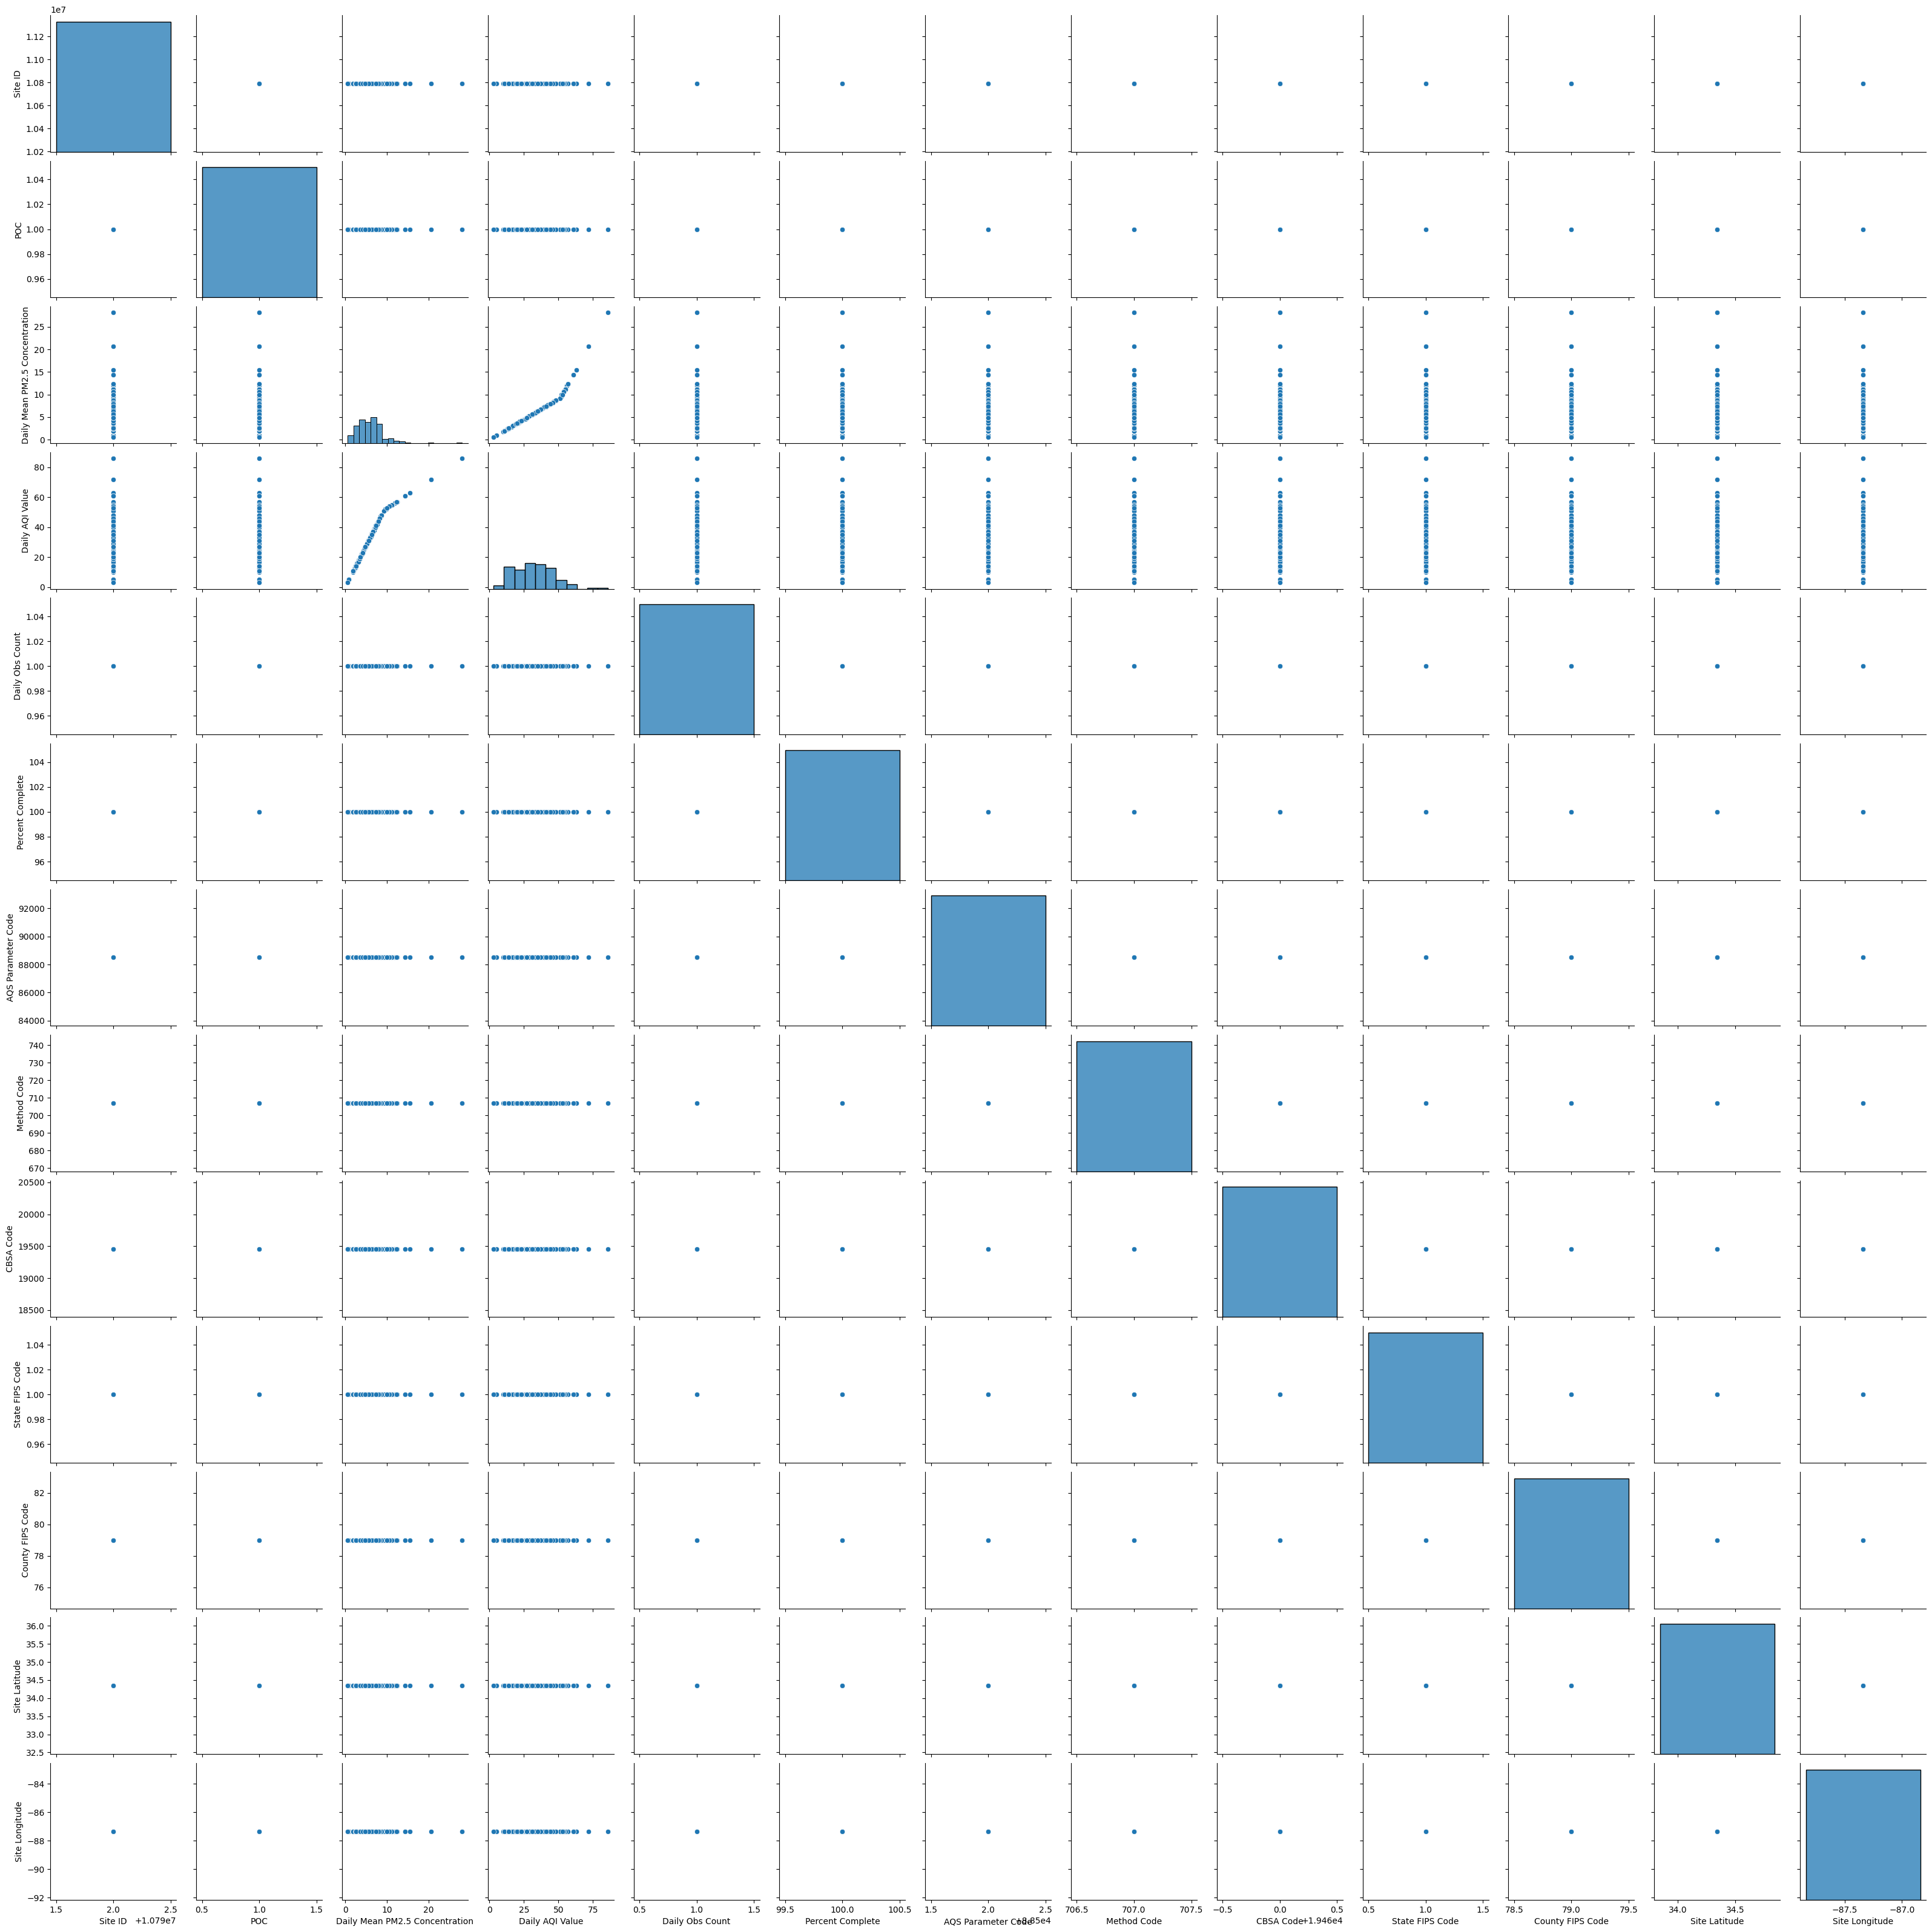

In [ ]:
sns.pairplot(df)

In [ ]:
#correlaciones
df.corr(numeric_only=True)

,Site ID,POC,Daily Mean PM2.5 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
Site ID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
POC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Daily Mean PM2.5 Concentration,NaN,NaN,1.000000,0.950941,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Daily AQI Value,NaN,NaN,0.950941,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Daily Obs Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Percent Complete,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AQS Parameter Code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Method Code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CBSA Code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State FIPS Code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='Daily Mean PM2.5 Concentration', ylabel='Count'>

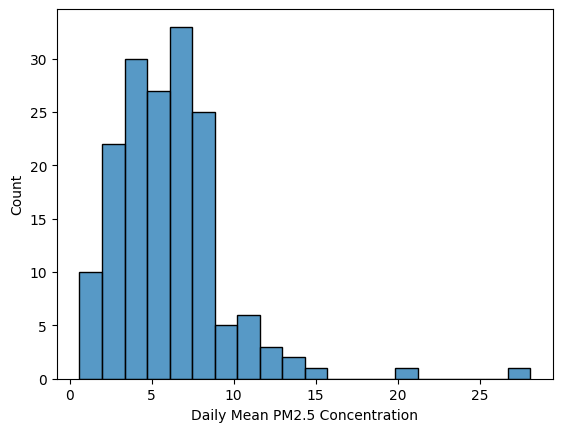

In [ ]:
import seaborn as sns
sns.histplot(df["Daily Mean PM2.5 Concentration"])